<a href="https://colab.research.google.com/github/2403A52058/ML_LAB_ASSIGNMENTS/blob/main/ML_LAB(12)_2403A52058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Import required libraries

This section imports all necessary Python libraries required for
data processing, visualization, model training, and evaluation.
"""

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [3]:
import pandas as pd

"""
Load dataset

This cell loads the credit card dataset.
Update the file path if needed.
"""

# Load dataset
df = pd.read_excel("/content/UCI_Credit_Card.xlsx")

# Display first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
"""
Data preprocessing

Steps performed:
1. Remove unnecessary columns
2. Separate features and target variable
3. Split data into training and testing sets
"""

# Remove ID column if present
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Target variable
y = df['default.payment.next.month']

# Feature variables
X = df.drop(columns=['default.payment.next.month'])

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (24000, 23)
Testing data shape: (6000, 23)


In [5]:
"""
Feature scaling

Standardization normalizes feature values to improve model performance.
"""

scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [6]:
"""
Train baseline Decision Tree model

This model acts as a baseline to compare with AdaBoost and Random Forest.
"""

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predict labels
dt_pred = dt_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

In [7]:
"""
Train AdaBoost model

AdaBoost improves performance by combining multiple weak learners.
"""

# Initialize AdaBoost classifier
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
ada_model.fit(X_train_scaled, y_train)

# Predictions
ada_pred = ada_model.predict(X_test_scaled)
ada_prob = ada_model.predict_proba(X_test_scaled)[:, 1]

In [9]:
"""
Train Random Forest models with different parameters.

We vary:
- n_estimators: number of trees
- max_depth: depth of each tree
"""

rf_results = []

# Parameter combinations
n_estimators_list = [50, 100, 200]
max_depth_list = [5, 10, None]

for n in n_estimators_list:
    for depth in max_depth_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )

        # Train model
        rf_model.fit(X_train_scaled, y_train)

        # Predictions
        rf_pred = rf_model.predict(X_test_scaled)
        rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

        # Calculate evaluation metrics
        acc = accuracy_score(y_test, rf_pred)
        prec = precision_score(y_test, rf_pred)
        rec = recall_score(y_test, rf_pred)
        roc = roc_auc_score(y_test, rf_prob)

        rf_results.append({
            "Model": f"RF (n={n}, depth={depth})",
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "ROC-AUC": roc
        })

In [10]:
"""
Evaluate Decision Tree and AdaBoost models using
Accuracy, Precision, Recall, and ROC-AUC metrics.
"""

results = []

# Decision Tree metrics
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "ROC-AUC": roc_auc_score(y_test, dt_prob)
})

# AdaBoost metrics
results.append({
    "Model": "AdaBoost",
    "Accuracy": accuracy_score(y_test, ada_pred),
    "Precision": precision_score(y_test, ada_pred),
    "Recall": recall_score(y_test, ada_pred),
    "ROC-AUC": roc_auc_score(y_test, ada_prob)
})

# Add Random Forest results
results.extend(rf_results)

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Decision Tree,0.725000,0.380242,0.407464,0.610829
1,AdaBoost,0.818167,0.680195,0.319117,0.774777
2,"RF (n=50, depth=5)",0.816667,0.690519,0.293983,0.770961
3,"RF (n=50, depth=10)",0.820500,0.669054,0.355674,0.775777
4,"RF (n=50, depth=None)",0.815833,0.639410,0.363290,0.753161
5,"RF (n=100, depth=5)",0.816833,0.680743,0.306931,0.770704
6,"RF (n=100, depth=10)",0.819000,0.662841,0.351866,0.777061
7,"RF (n=100, depth=None)",0.816000,0.638411,0.367098,0.757042
8,"RF (n=200, depth=5)",0.817833,0.682119,0.313785,0.770626
9,"RF (n=200, depth=10)",0.819000,0.661912,0.353389,0.777867


In [11]:
"""
Compare model performance

Sort models based on ROC-AUC score.
"""

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df)

                     Model  Accuracy  Precision    Recall   ROC-AUC
9     RF (n=200, depth=10)  0.819000   0.661912  0.353389  0.777867
6     RF (n=100, depth=10)  0.819000   0.662841  0.351866  0.777061
3      RF (n=50, depth=10)  0.820500   0.669054  0.355674  0.775777
1                 AdaBoost  0.818167   0.680195  0.319117  0.774777
2       RF (n=50, depth=5)  0.816667   0.690519  0.293983  0.770961
5      RF (n=100, depth=5)  0.816833   0.680743  0.306931  0.770704
8      RF (n=200, depth=5)  0.817833   0.682119  0.313785  0.770626
10  RF (n=200, depth=None)  0.815333   0.635403  0.366337  0.760907
7   RF (n=100, depth=None)  0.816000   0.638411  0.367098  0.757042
4    RF (n=50, depth=None)  0.815833   0.639410  0.363290  0.753161
0            Decision Tree  0.725000   0.380242  0.407464  0.610829


In [12]:
"""
Identify best-performing model

The model with the highest ROC-AUC score
is considered the best model.
"""

best_model = results_df.iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        RF (n=200, depth=10)
Accuracy                    0.819
Precision                0.661912
Recall                   0.353389
ROC-AUC                  0.777867
Name: 9, dtype: object


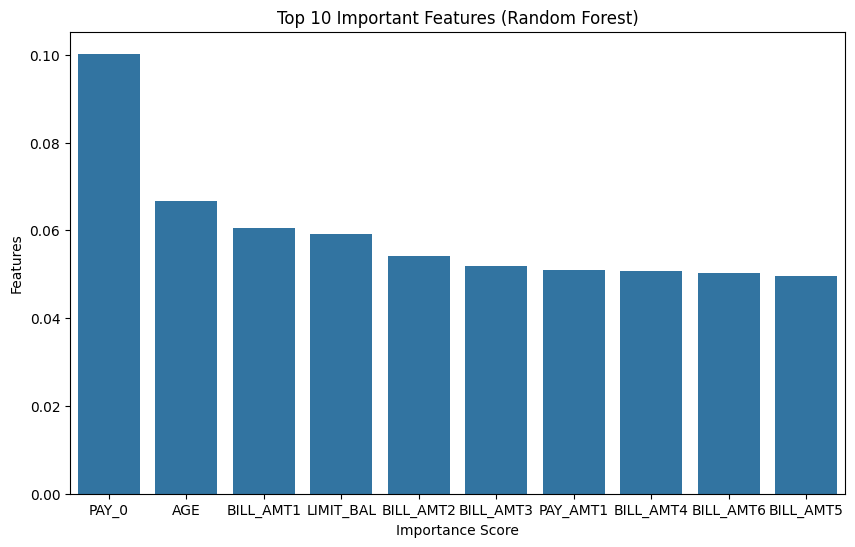

In [17]:
"""
Train best Random Forest model and plot feature importance
"""

# Train the best Random Forest model
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train)

# Get feature importance values
importance = best_rf.feature_importances_

# Create DataFrame for visualization
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort features
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(
    y="Importance",
    x="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()